Input shape : (178, 13)
Output shape: (178,)
Classes     : ['class_0' 'class_1' 'class_2']

Initial W1 shape: (13, 8)
Initial W2 shape: (8, 3)
Epoch  50 | Loss: 1.0331 | Accuracy: 0.5775
Epoch 100 | Loss: 0.9351 | Accuracy: 0.6620
Epoch 150 | Loss: 0.7863 | Accuracy: 0.9296
Epoch 200 | Loss: 0.6265 | Accuracy: 0.9507
Epoch 250 | Loss: 0.4908 | Accuracy: 0.9718
Epoch 300 | Loss: 0.3881 | Accuracy: 0.9859
Epoch 350 | Loss: 0.3134 | Accuracy: 0.9859
Epoch 400 | Loss: 0.2592 | Accuracy: 0.9859
Epoch 450 | Loss: 0.2191 | Accuracy: 0.9930
Epoch 500 | Loss: 0.1887 | Accuracy: 0.9930

Training completed!
Test Accuracy: 1.0


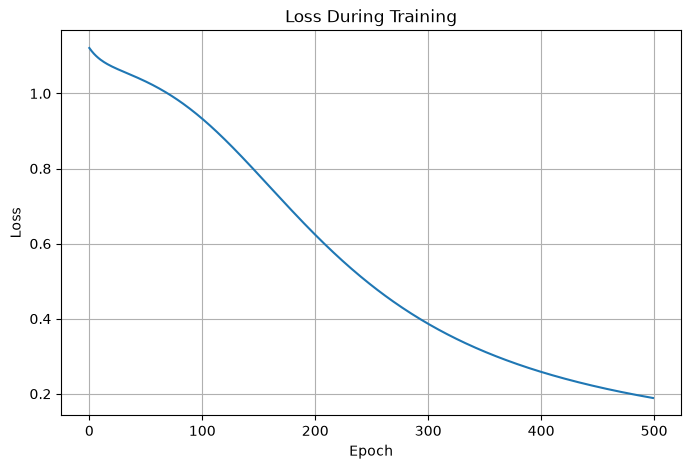

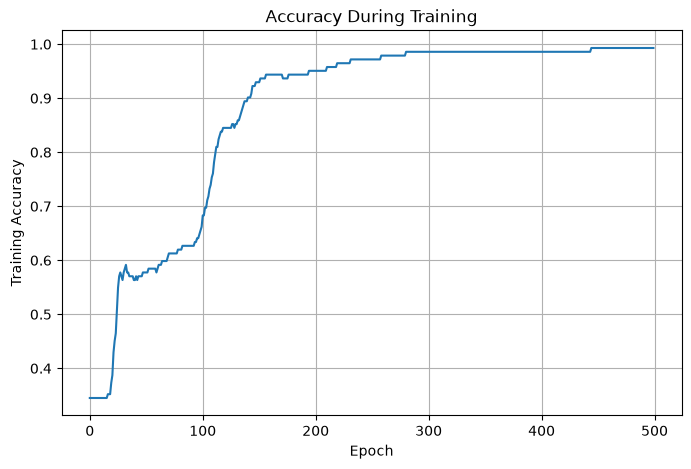

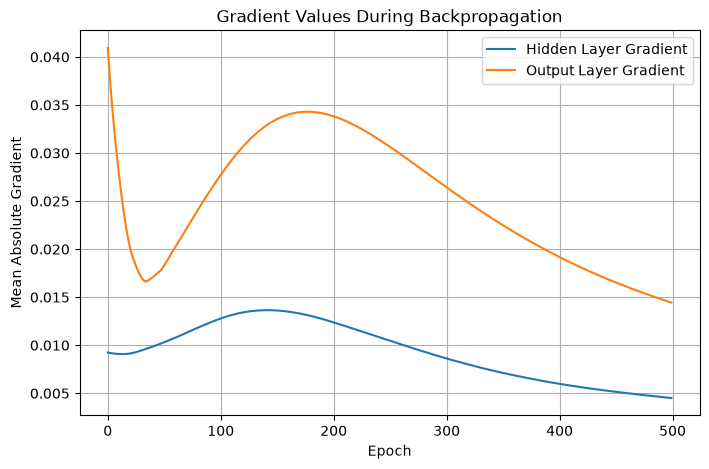

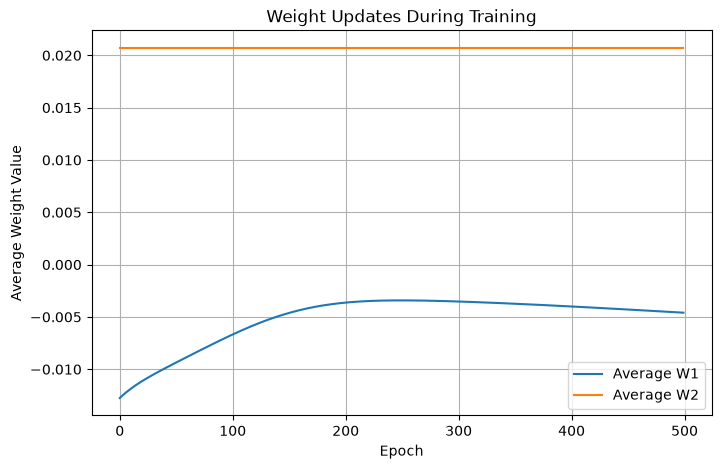

In [9]:
#import different libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine  #for wine dataset
from sklearn.model_selection import train_test_split  #to split the training and testing dataset
from sklearn.preprocessing import StandardScaler   #for standardization

# 1. Load Wine Dataset
wine = load_wine()    #loads dataset into a variable

X = wine.data   #contains input features- 178 samples, 13 input features
y = wine.target  #contains output/ classes

print("Input shape :", X.shape)
print("Output shape:", y.shape)
print("Classes     :", wine.target_names) #to print the statements or values

# Wine dataset:
# 178 samples
# 13 input features
# 3 output classes


# 2. Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,   #20% for testing data
    random_state=20, #controls the train/test split
)


# 3. Standardize Input
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  #scaler learns the mean and standard deviation from the training data and converts it into standardized values
X_test = scaler.transform(X_test)  ##scaler learns the mean and standard deviation from the testing data and converts it into standardized values


# 4. One-Hot Encoding- 3 classes 0,1,2
num_classes = 3

Y_train = np.eye(num_classes)[y_train]
#[1 0 0]
#[0 1 0]
#[0 0 1]
Y_test = np.eye(num_classes)[y_test]


# 5. Network Structure or design the neural network
input_size = 13
hidden_size = 8
output_size = 3

learning_rate = 0.05 #[W(new) = W(old) − learningrate × gradient]
epochs = 500


# 6. Initialize Weights and Biases
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))


print("\nInitial W1 shape:", W1.shape)
print("Initial W2 shape:", W2.shape)


# 7. Activation Functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)


def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# 8. Storage for Visualization
loss_history = []
accuracy_history = []

gradient_W1_history = []
gradient_W2_history = []

weight_W1_history = []
weight_W2_history = []


# 9. Training
for epoch in range(epochs):


    # FORWARD PROPAGATION

    # Input -> Hidden Layer
    Z1 = np.dot(X_train, W1) + b1
    A1 = sigmoid(Z1)

    # Hidden -> Output Layer
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)



    # LOSS
    loss = -np.mean(
        np.sum(Y_train * np.log(A2 + 1e-8), axis=1)
    )

    loss_history.append(loss)


    # PREDICTION
    predictions = np.argmax(A2, axis=1)

    accuracy = np.mean(predictions == y_train)

    accuracy_history.append(accuracy)


    # BACKPROPAGATION
    # Output layer error
    dZ2 = A2 - Y_train

    # Gradient of W2
    dW2 = np.dot(A1.T, dZ2) / len(X_train)

    # Gradient of bias b2
    db2 = np.sum(dZ2, axis=0, keepdims=True) / len(X_train)


    # Hidden layer error
    dA1 = np.dot(dZ2, W2.T)

    # Apply derivative of sigmoid
    dZ1 = dA1 * sigmoid_derivative(A1)

    # Gradient of W1
    dW1 = np.dot(X_train.T, dZ1) / len(X_train)

    # Gradient of bias b1
    db1 = np.sum(dZ1, axis=0, keepdims=True) / len(X_train)



    # STORE GRADIENTS


    gradient_W1_history.append(np.mean(np.abs(dW1)))
    gradient_W2_history.append(np.mean(np.abs(dW2)))


    # WEIGHT UPDATE


    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1


    # Store average weights
    weight_W1_history.append(np.mean(W1))
    weight_W2_history.append(np.mean(W2))



    # DISPLAY


    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch {epoch + 1:3d} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy:.4f}"
        )



# 10. Test the Network
Z1_test = np.dot(X_test, W1) + b1
A1_test = sigmoid(Z1_test)

Z2_test = np.dot(A1_test, W2) + b2
A2_test = softmax(Z2_test)

test_predictions = np.argmax(A2_test, axis=1)

test_accuracy = np.mean(test_predictions == y_test)

print("\nTraining completed!")
print("Test Accuracy:", test_accuracy)


# 11. Visualize Loss
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Training")

plt.grid()
plt.show()


# 12. Visualize Accuracy
plt.figure(figsize=(8, 5))

plt.plot(accuracy_history)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Accuracy During Training")

plt.grid()
plt.show()



# 13. Visualize Gradients
plt.figure(figsize=(8, 5))

plt.plot(
    gradient_W1_history,
    label="Hidden Layer Gradient"
)

plt.plot(
    gradient_W2_history,
    label="Output Layer Gradient"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Gradient")
plt.title("Gradient Values During Backpropagation")

plt.legend()
plt.grid()
plt.show()


# 14. Visualize Weight Updates
plt.figure(figsize=(8, 5))

plt.plot(
    weight_W1_history,
    label="Average W1"
)

plt.plot(
    weight_W2_history,
    label="Average W2"
)

plt.xlabel("Epoch")
plt.ylabel("Average Weight Value")
plt.title("Weight Updates During Training")

plt.legend()
plt.grid()
plt.show()